In [26]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np


In [3]:
df = pd.read_csv('steam_games_cleaned.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   game_name         1964 non-null   object 
 1   price             1964 non-null   float64
 2   review_count      1964 non-null   int64  
 3   developer         1964 non-null   object 
 4   publisher         1964 non-null   object 
 5   genres            1951 non-null   object 
 6   release_year      1964 non-null   int64  
 7   release_month     1964 non-null   int64  
 8   review_sentiment  1964 non-null   object 
 9   review_score      1964 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 153.6+ KB


In [7]:
df.describe()

,price,review_count,release_year,release_month,review_score
count,1964.000000,1.964000e+03,1964.000000,1964.000000,1964.000000
mean,1124.301426,2.172748e+04,2021.950611,6.606415,82.809572
std,1128.286731,8.006495e+04,4.034253,3.611464,13.230293
min,0.000000,1.000000e+01,1998.000000,1.000000,17.000000
25%,389.750000,1.187000e+03,2020.000000,3.000000,76.000000
50%,770.000000,4.302000e+03,2023.000000,7.000000,86.000000
75%,1499.000000,1.586375e+04,2025.000000,10.000000,93.000000
max,10874.000000,2.496132e+06,2026.000000,12.000000,100.000000


In [17]:
num_cols = ['price','review_count','release_year','release_month','review_score']
cat_cols = ['developer','publisher','genres','review_sentiment']

In [19]:
len(num_cols)

5

num cols = 5

cat cols = 5

**UNIVARIATE ANALYSIS**

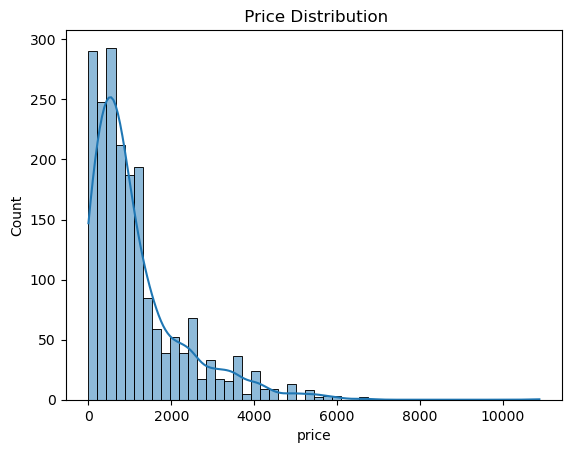

In [48]:
cols = ['price','review_count']
sns.histplot(x=df['price'],bins=50,kde=True)
plt.title(" Price Distribution")
plt.show()

Price Distribution Insights

A large number of games are free-to-play, which creates a strong peak near price = 0.

Most paid games fall within the ₹500 – ₹2000 price range, indicating that this is the most common pricing range for games.

Only a small number of games are priced above ₹2000, suggesting premium-priced titles are less common.

The distribution is right-skewed, meaning most games are priced at lower values while a few games have very high prices.

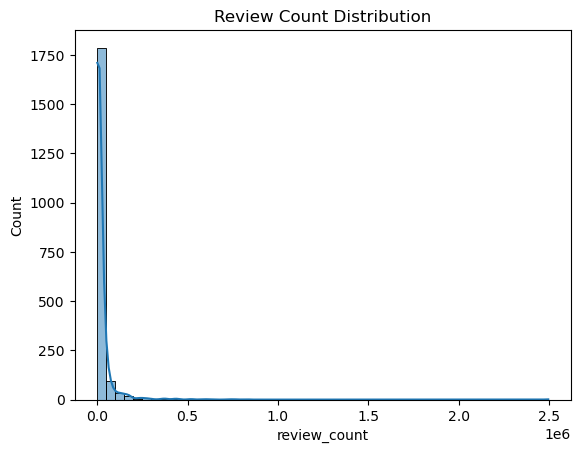

In [58]:
sns.histplot(df['review_count'], bins=50, kde=True)
plt.title("Review Count Distribution")
plt.show()

The review_count distribution is highly right-skewed. Most games receive relatively few reviews, while a small number of games receive extremely large numbers of reviews.

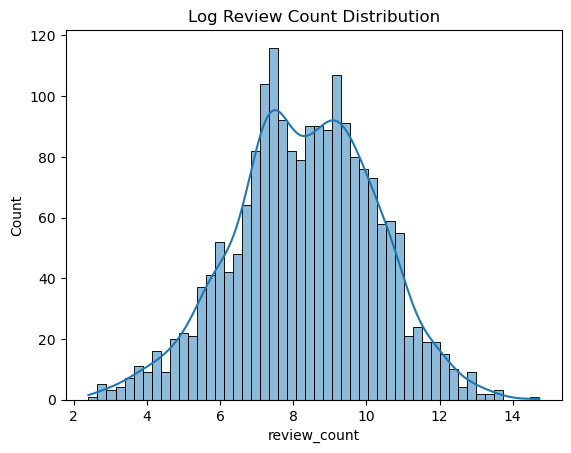

In [46]:
sns.histplot(np.log1p(df['review_count']), bins=50, kde=True)
plt.title("Log Review Count Distribution")
plt.show()

After applying a log transformation (log1p), the distribution becomes approximately normal, reducing skewness and making the variable more suitable for machine learning models.

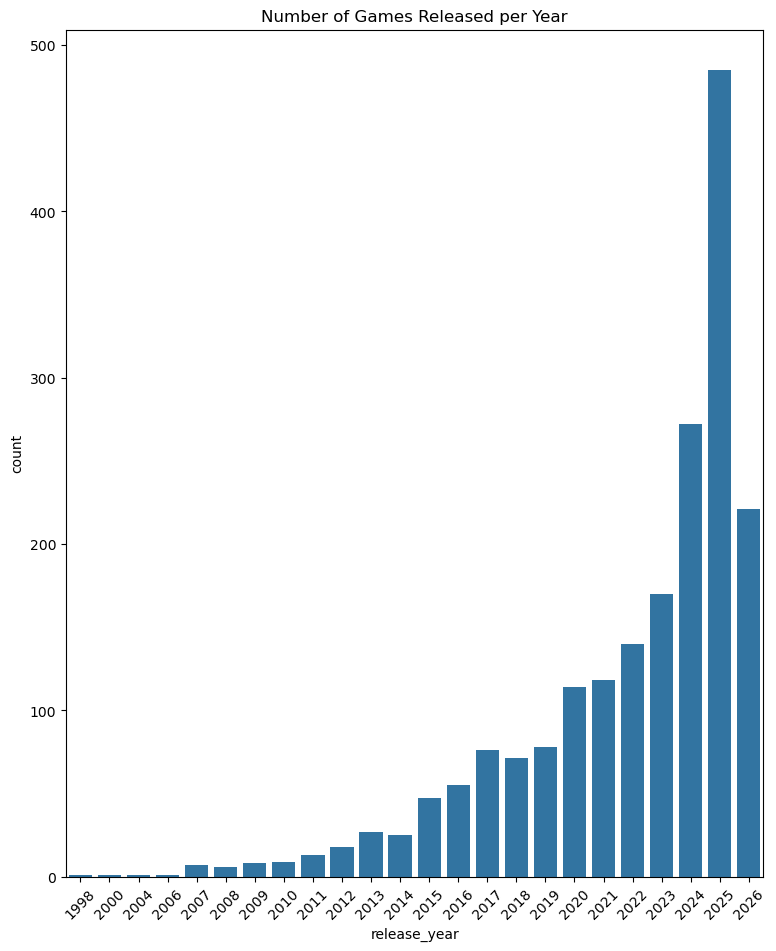

In [78]:
plt.figure(figsize=(9,11))
sns.countplot(x='release_year', data=df, order=sorted(df['release_year'].unique()))

plt.title("Number of Games Released per Year")
plt.xticks(rotation=45)
plt.show()

Release Year Distribution

The number of games released on the platform has gradually increased over the years.

Earlier years show very few releases, while more recent years contain significantly more games.

The highest number of games in this dataset were released around 2024–2025.

This trend suggests that the game industry has been growing over time, with more titles being released in recent years.

Release Year Distribution

The number of games released on the platform has gradually increased over the years.

Earlier years show very few releases, while more recent years contain significantly more games.

The highest number of games in this dataset were released around 2024–2025.

The dataset is more concentrated on recent releases, likely because modern games are more visible in current Steam listings.

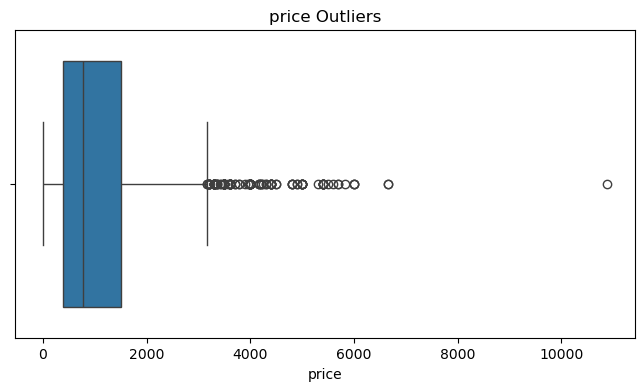

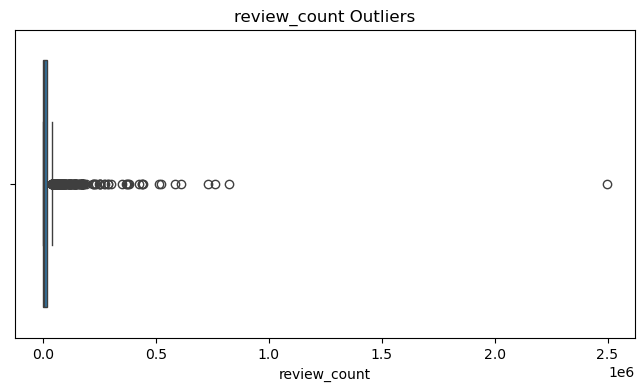

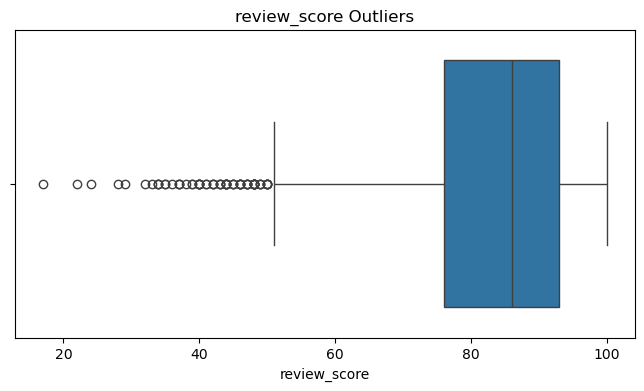

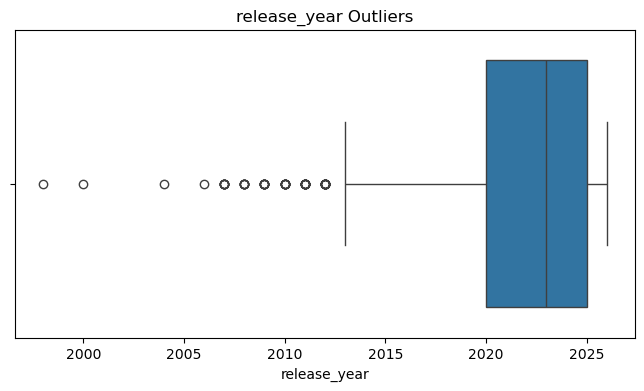

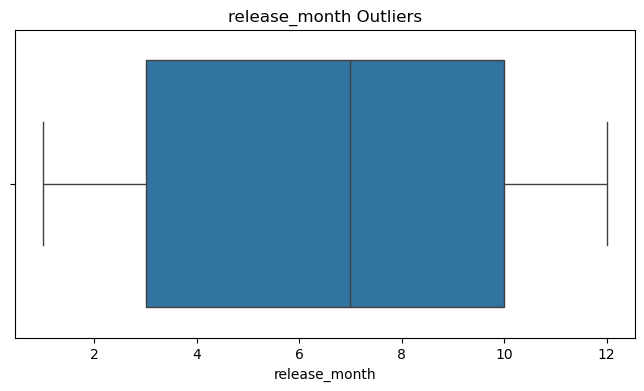

In [86]:
num_cols = ['price','review_count','review_score','release_year','release_month']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Outliers")
    plt.show()

Price Outliers :

The boxplot reveals several high price values that appear as outliers.

However, these values represent premium or deluxe game editions, which are valid prices in the dataset.

Therefore, these observations are not removed, as they represent legitimate market behavior.

Review Score Outliers

The boxplot shows that most games have review scores between 70 and 90, indicating generally positive feedback. A few lower values appear as outliers, representing games with significantly lower user ratings compared to the majority.

Review Score Outliers

The boxplot shows that most games have review scores between 70 and 90, indicating generally positive feedback. A few lower values appear as outliers, representing games with significantly lower user ratings compared to the majority.

Release Year Outliers

The boxplot indicates that most games in the dataset were released between 2018 and 2025. Older games appear as outliers because the dataset is concentrated on more recent releases.

Review Count Boxplot

The boxplot reveals extreme outliers in review_count, where a few games have extremely large numbers of reviews. Since popularity data naturally contains such extreme values, a log transformation was applied to stabilize the distribution and reduce the impact of these outliers.

**BIVARIATE ANALYSIS**

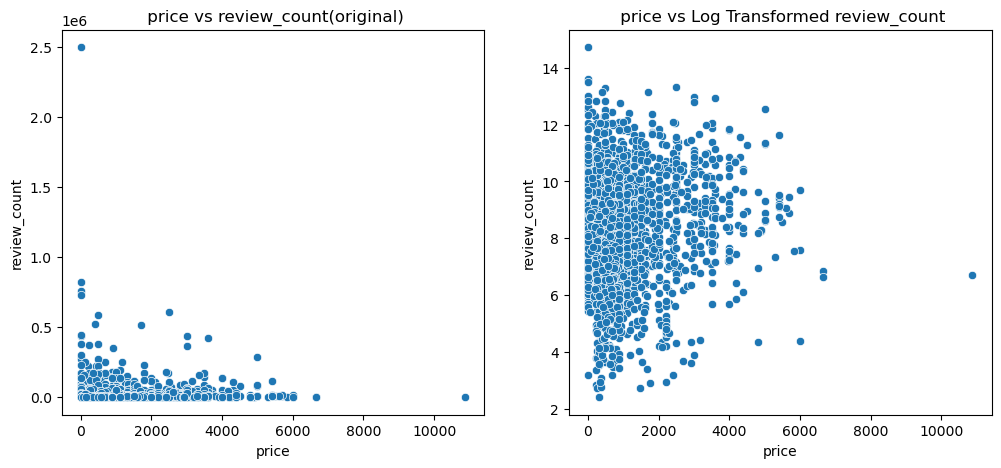

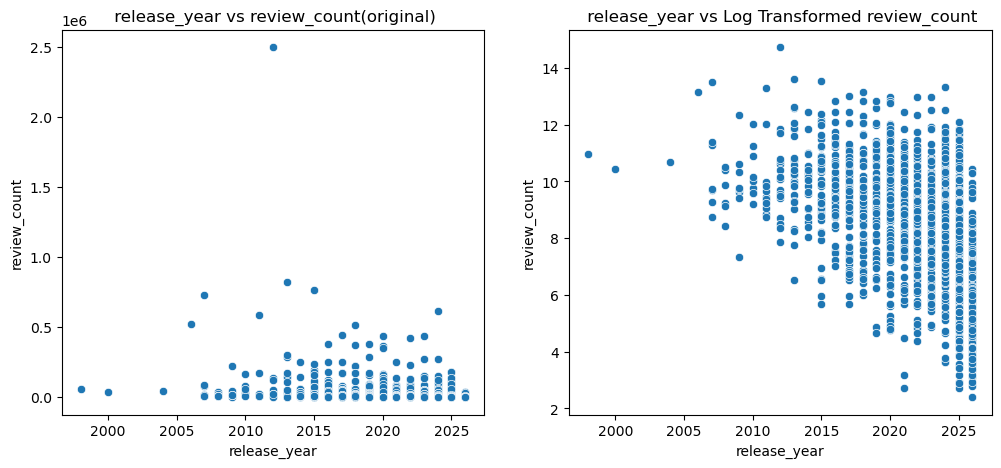

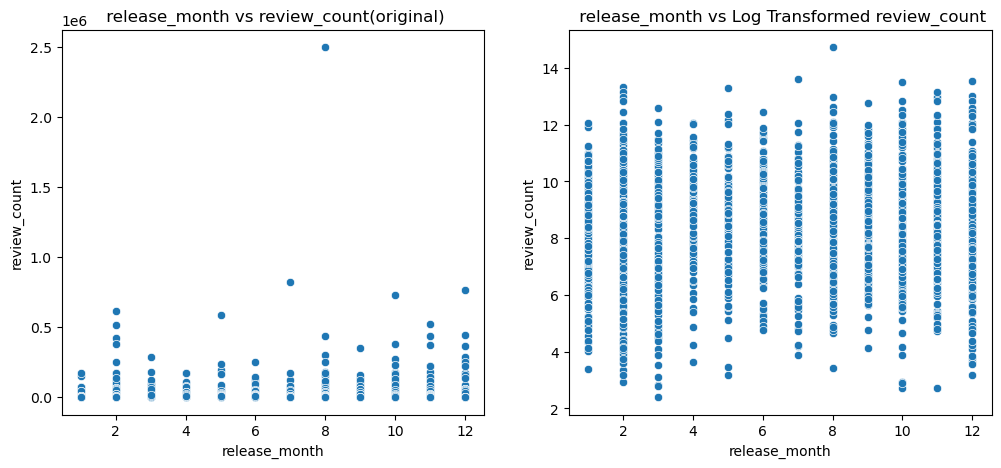

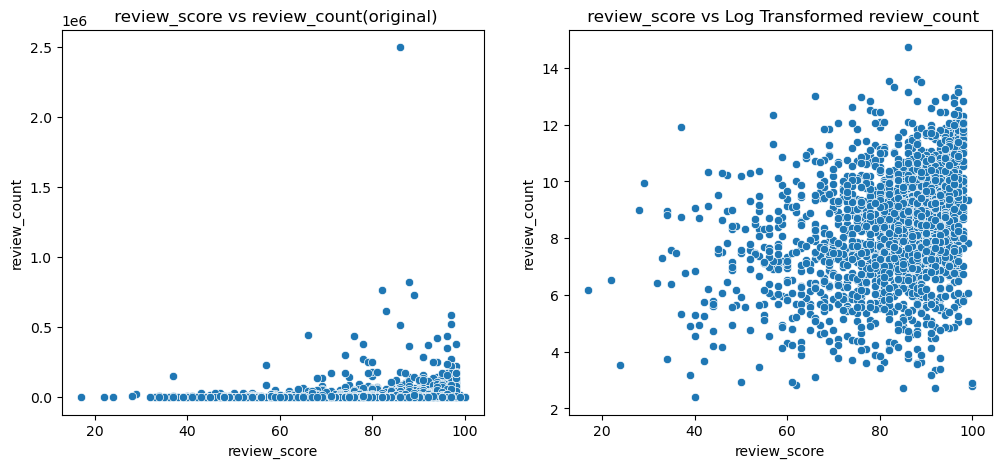

In [99]:
num_cols = ['price','release_year','release_month','review_score']
for cols in num_cols : 
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    sns.scatterplot(x=cols,y='review_count',data=df)
    plt.title(f" {cols} vs review_count(original)")
    
    plt.subplot(1,2,2)
    sns.scatterplot(x=cols,y=np.log1p(df['review_count']),data=df)
    plt.title(f" {cols} vs Log Transformed review_count")
    plt.show()
    

Price vs Review Count :

The scatter plot illustrates the relationship between game price and the number of user reviews.
In the original plot, extreme values in review counts create strong skewness, making patterns difficult to observe.
After applying a log transformation (log1p), the distribution becomes more compressed and easier to interpret.
The transformed plot suggests that most highly reviewed games are either free or moderately priced, while very expensive games generally receive fewer reviews.

Release Year vs Review Count :

The relationship between release year and review count indicates that more recent games tend to accumulate larger numbers of reviews.
However, the original plot is heavily skewed due to extremely popular titles with unusually high review counts.
After applying a log transformation, the distribution becomes more interpretable and shows that games released in recent years generally receive higher levels of player engagement.

Release Month vs Review Count :

The scatter plot explores whether the month of release influences the number of reviews a game receives.
In the original plot, extreme values dominate the scale, making it difficult to observe general patterns.
After applying the log transformation, the spread of values becomes clearer.
The transformed visualization suggests that no strong seasonal pattern exists between release month and review count.

Review Score vs Review Count :

The scatter plot shows the relationship between review score and review count, which serves as a proxy for game popularity.
In the original visualization, extreme review counts obscure the relationship.
After applying a log transformation, the pattern becomes clearer, showing that games with higher review scores tend to accumulate more reviews.
This suggests that positive user feedback may contribute to greater player engagement and popularity.

**MULTIVARIATE ANALYSIS**

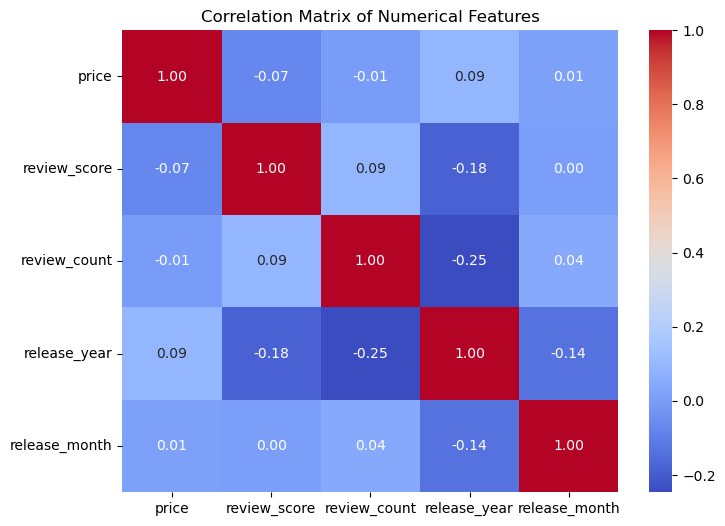

In [104]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['price','review_score','review_count','release_year','release_month']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

Correlation Heatmap

The correlation heatmap summarizes the linear relationships between numerical features in the dataset.
Most variables show very weak correlations with each other, indicating that the features capture different aspects of the data and there is little multicollinearity present.

A slight positive relationship can be observed between review score and review count, suggesting that games with better user ratings tend to attract more engagement from players.

A moderate negative relationship appears between release year and review count, which likely occurs because older games have had more time to accumulate reviews compared to newly released titles.

Overall, the heatmap suggests that game popularity is influenced by multiple factors rather than a single dominant feature.

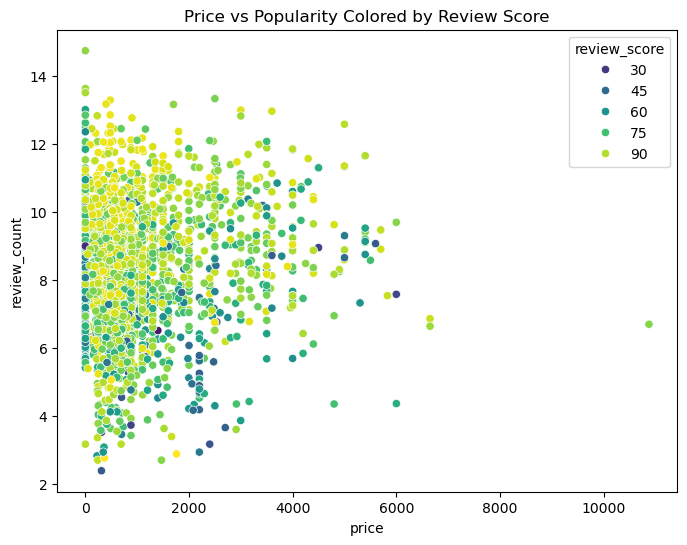

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='price',
    y=np.log1p(df['review_count']),
    hue='review_score',
    palette='viridis'
)

plt.title("Price vs Popularity Colored by Review Score")
plt.show()

Price vs Popularity (Colored by Review Score)

This scatter plot visualizes the relationship between game price and popularity, with color representing the review score of each game.

The plot indicates that highly popular games appear across a wide range of price points, suggesting that price alone does not strongly determine game popularity.

However, a visible pattern emerges in the coloring: games with higher review scores tend to cluster at higher popularity levels, indicating that positive user feedback plays an important role in attracting player engagement.

This suggests that game quality and user satisfaction may have a stronger influence on popularity than pricing alone.